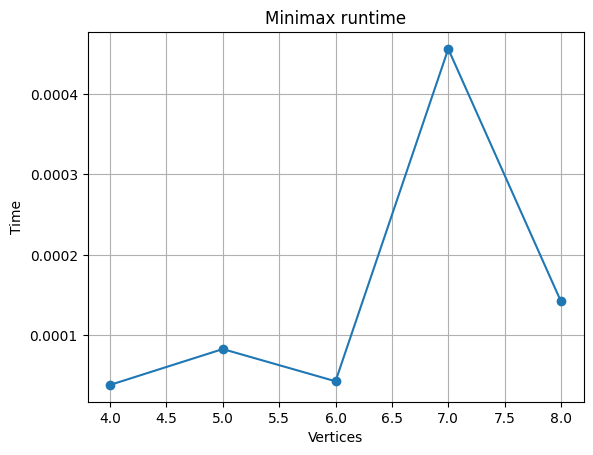

In [2]:
import random
import time
import matplotlib.pyplot as plt


def generate_graph(n, p=0.3):
    graph = {i: [] for i in range(n)}

    for i in range(n):
        for j in range(i+1, n):
            if random.random() < p:
                graph[i].append(j)
                graph[j].append(i)

    weights = {i: random.randint(1, 10) for i in range(n)}
    return graph, weights


def available(graph, chosen):
    forbidden = set(chosen)

    for v in chosen:
        forbidden.update(graph[v])

    return [v for v in graph if v not in forbidden]


def minimax(graph, weights, chosen, player, score):
    moves = available(graph, chosen)

    if not moves:
        return score

    if player == 2:   # maximize
        best = -1000
        for v in moves:
            value = minimax(graph, weights, chosen+[v], 1, score + weights[v])
            best = max(best, value)
        return best
    else:             # minimize
        best = 1000
        for v in moves:
            value = minimax(graph, weights, chosen+[v], 2, score)
            best = min(best, value)
        return best


sizes = [4,5,6,7,8]
times = []

for n in sizes:
    graph, weights = generate_graph(n)

    start = time.time()
    minimax(graph, weights, [], 1, 0)
    end = time.time()

    times.append(end-start)


plt.plot(sizes, times, marker='o')
plt.xlabel("Vertices")
plt.ylabel("Time")
plt.title("Minimax runtime")
plt.grid()
plt.show()